# Estimation

This notebook estimates the job-search model

**Order of estimation**
1. L-BFGS-B: Standard 1-type, Standard 2-type, Standard 3-type, Reference-dependent 1-type.
2. LS-TRF: Standard 1-type, Standard 2-type, Standard 3-type, Reference-dependent 1-type.

For the **standard model**, `eta = 0` and `lambda = 0` are fixed. We estimate `delta`, `gamma`, the relevant search-cost parameters `k`, and the type shares `q`. `N` is fixed.

For the **reference-dependent model**, we use one type and estimate `delta`, `gamma`, `eta`, `k`, and `lambda`, while keeping `N` fixed.

This notebook produces:
- initial-fit and post-estimation hazard plots;
- estimation tables in both DataFrame and LaTeX form;
- goodness of fit (SSE);
- elapsed estimation time;
- a type-survival / survivor-composition for heterogeneous-type models.

## 1. Setup

Set `MODEL_DIR` to the folder containing `Model_components.py` if needed. The code below uses the same local path as the existing notebook by default.

In [1]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
import sys
import time

import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate 
import optimagic as om
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
from scipy.stats import beta


MODEL_DIR = os.environ.get(
    "JOB_SEARCH_MODEL_DIR",
    "C:\\Users\\jap\\OneDrive - ROCKWOOL FONDEN\\Python Workspace\\termpaper_dynprog\\Job Search\\"
)

MODEL_DIR = os.environ.get(
    "JOB_SEARCH_MODEL_DIR",
    '/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Job Search'
)



if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

import Model_components_copy as model

FIGURE_DIR = os.path.join(os.getcwd(), "estimation_figures")
TABLE_DIR = os.path.join(os.getcwd(), "estimation_tables")
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.5f}")

## 2. Parameters and institutions

The computational asset grid and the initial asset distribution are separate objects. `abar` controls the state space; `weights` controls how initial asset states are represented in the simulated population.

For faster exploratory estimation, reduce `n_a` and/or `n_c`. Re-solve the final estimates on a finer grid as a robustness check.

In [2]:
# Baseline structural values / starting values
delta = 0.89
gamma = 0.81
eta_rd = 1.0
beta = 0.8

k = 359.0
k1 = 300.0
k2 = 150.0
k3 = 90.0

q1 = 0.33
q2 = 0.33

lmbda_rd = 4.9
N = 6

# Asset state space
abar = [0, 17955]

# Grid sizes
n_a = 50
n_c = 100

# Timing
T1 = 6
T2 = 18
T3 = 24
T = 44

# Pre-reform benefits
b1_pre = 222
b2_pre = 222
b3 = 114

# Post-reform benefits
b1_post = 342
b2_post = 171

welfare = 90
w = 675
R = 0.01

# 0 = heterogeneous assets; 1 = hand-to-mouth
htm = 0

institutions_pre = np.array([
    n_a, n_c, T1, T2, T3, T,
    b1_pre, b2_pre, b3, welfare, w, R
])

institutions_post = np.array([
    n_a, n_c, T1, T2, T3, T,
    b1_post, b2_post, b3, welfare, w, R
])

weights = model.make_weights(htm, abar, n_a)

target, cov = model.matchingMoments()
W = np.linalg.inv(cov)

# matchingMoments() drops the first empirical 15-day moment.
# Hence 35 retained observations correspond to days 30,...,540.
timevec = np.arange(15, 526, 15)

def split_half(arr):
    arr = np.asarray(arr)
    mid = len(arr) // 2
    return arr[:mid], arr[mid:]

emp_pre, emp_post = split_half(target)

print("Number of moments:", len(target))
print("Asset weights sum to:", weights.sum())

Number of moments: 70
Asset weights sum to: 1.0000000000000002


# Nu kører jeg modellen med beta blot for at se om det virker

In [4]:
pb_model = model

params = delta, gamma, eta_rd, k, lmbda_rd, N

cons, search, survival, assets, asset_grid, benefits = model.SolveForward(params, beta, institutions_pre, abar=abar, htm=htm)

TypeError: SolveForward() got multiple values for argument 'abar'

In [10]:
print(search.shape)
print(cons.shape)
print(survival.shape)
print(assets.shape) 

(50, 44)
(50, 44)
(50, 45)
(50, 45)


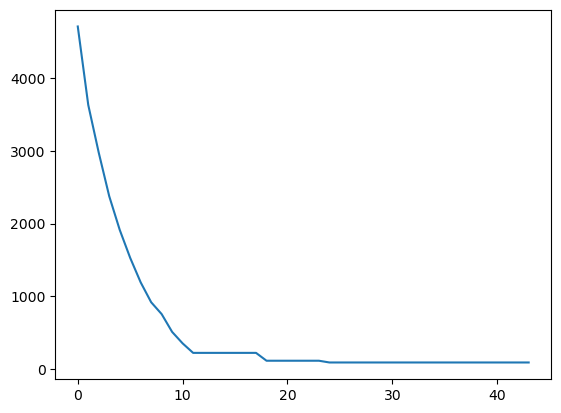

In [73]:
plt.figure(figsize=(6.4, 4.8))

plt.plot(cons[49,:])
#plt.ylim(0, 0.05)

plt.show()

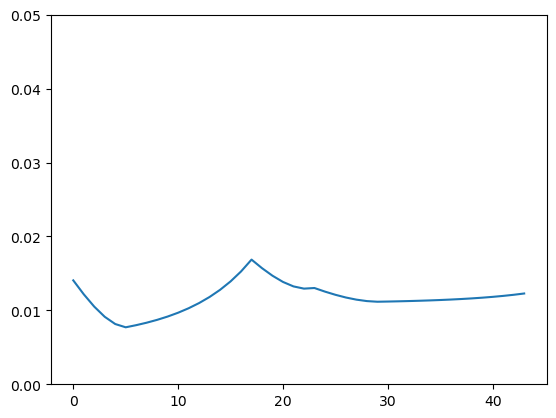

In [74]:
plt.figure(figsize=(6.4, 4.8))

plt.plot(search[0,:])
plt.ylim(0, 0.05)

plt.show()
